In [81]:
from keras.utils import to_categorical
from keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import load_img
from PIL import Image

from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout,Flatten,MaxPooling2D
import os
import pandas as pd
import numpy as np

In [63]:
Train_Dir = "images/train"
Test_Dir="images/Test"

In [64]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [65]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(Train_Dir)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [66]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [67]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(Test_Dir)


angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [68]:
print(test)

                              image     label
0       images/Test\angry\10052.jpg     angry
1       images/Test\angry\10065.jpg     angry
2       images/Test\angry\10079.jpg     angry
3       images/Test\angry\10095.jpg     angry
4       images/Test\angry\10121.jpg     angry
...                             ...       ...
7061  images/Test\surprise\9806.jpg  surprise
7062  images/Test\surprise\9830.jpg  surprise
7063  images/Test\surprise\9853.jpg  surprise
7064  images/Test\surprise\9878.jpg  surprise
7065   images/Test\surprise\993.jpg  surprise

[7066 rows x 2 columns]


In [69]:
from tqdm.notebook import tqdm

In [92]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image,grayscale =  True )
        img = np.array(img)
        features.append(img)
    features = np.array(features)
    features = features.reshape(len(features),48,48,1)
    return features

In [93]:
train_features = extract_features(train['image']) 


  0%|          | 0/28821 [00:00<?, ?it/s]

In [ ]:
def load_img(path, grayscale=False, target_size=None):
    from PIL import Image
    img = Image.open(path)
    if grayscale:
        img = img.convert('L')
    else: 
        img = img.convert('RGB')
    return img

In [94]:

test_features = extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [95]:
x_train = train_features/255.0
x_test = test_features/255.0

In [98]:

from sklearn.preprocessing import LabelEncoder

In [99]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [100]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [101]:
y_train = to_categorical(y_train,num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [102]:
model = Sequential()
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(7, activation='softmax'))

c:\Users\saura\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy']) 

In [109]:

model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 100, validation_data = (x_test,y_test)) 

Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 108s 463ms/step - accuracy: 0.2171 - loss: 0.4300 - val_accuracy: 0.2583 - val_loss: 0.3942
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 93s 413ms/step - accuracy: 0.2375 - loss: 0.3925 - val_accuracy: 0.2600 - val_loss: 0.3870
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 107s 473ms/step - accuracy: 0.2584 - loss: 0.3865 - val_accuracy: 0.3248 - val_loss: 0.3633
Epoch 4/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 114s 505ms/step - accuracy: 0.3460 - loss: 0.3595 - val_accuracy: 0.4312 - val_loss: 0.3258
Epoch 5/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 94s 416ms/step - accuracy: 0.4145 - loss: 0.3316 - val_accuracy: 0.4928 - val_loss: 0.3001
Epoch 6/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 119s 527ms/step - accuracy: 0.4579 - loss: 0.3149 - val_accuracy: 0.5016 - val_loss: 0.2955
Epoch 7/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 166s 736ms/step - accuracy: 0.4716 - loss: 0.3079 - val_accuracy: 0.5231 - val_loss: 0.2835
Epoch 8/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 97s 430ms/step - accuracy: 0.4

KeyboardInterrupt: 

In [110]:
model_json = model.to_json()
with open("emotiondetector.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector.h5")

In [111]:
from keras.models import model_from_json

In [116]:
json_file = open("emotiondetector.json", "r")
model_json = json_file.read()
json_file.close()
model = model_from_json(model_json)
model.load_weights("emotiondetector.h5")

In [117]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']


In [118]:
def ef(image):
    img = load_img(image,grayscale =  True )
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0
    

In [134]:
image = 'images/train/sad/63.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
model prediction is  sad


In [136]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
model prediction is  sad


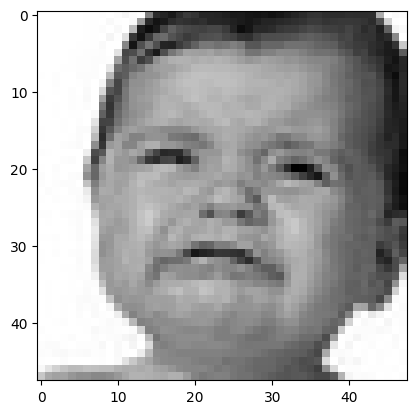

In [139]:
image = 'images/train/sad/63.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
model prediction is  fear


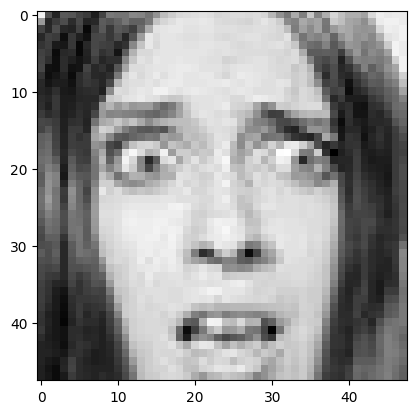

In [143]:
image = 'images/train/fear/96.jpg'
print("original image is of fear")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
model prediction is  fear


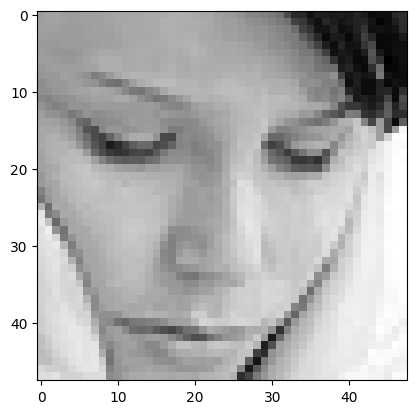

In [145]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
model prediction is  disgust


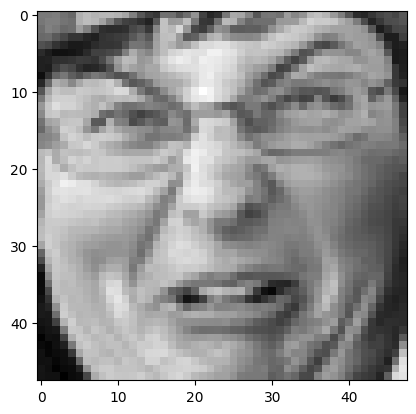

In [146]:
image = 'images/train/disgust/299.jpg'
print("original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')